## Intro

- make sure to save plots to different directories or under different names in EN and DE version
- add screenshots for EN
- distinguish between EN and DE csv files and ipynb files
- NOT: update readme (update files, reference to both language). do that in the existing readme
- update german notebook for EN/DE distinction

## Imports

In [1]:
# for data scraping
import requests
from bs4 import BeautifulSoup
import pandas as pd
import numpy as np
import sys

In [2]:
# for numerical data analysis
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# for language analysis
import spacy
# the spaCy package comes without a model, it must be loaded separately
# we use an english model (en) of small size (sm) trained on web data (web)
# we do this by commenting IN the following line on the first run of the notebook
# !python -m spacy download en_core_web_sm

In [4]:
# now we load the language model
nlp = spacy.load("en_core_web_sm")

## Data scraping

We are interested in data from website such as this one: https://www.sephora.co.uk/fragrances

Note the website's structure and address may be subject to change, so the `request` below may require modifications in the future.

### Product listings page

The listings page containts product names, prices and the individual product pages (details pages).

In [5]:
# construct the product listings url by gender
url_product_list = {}
genders = ["women", "men"]
for gender in genders:
    url_base = "https://www.sephora.co.uk/fragrances"
    url_filter = "?filter=fh_location=//c1/en_GB/categories%3C{c1_c1c2}/hisandhers%3E"
    url_gender = "{2}" if gender == "women" else "{1}" # filter query for gender
    url_end = "/!brand={a70}/!restricted=1/%26fh_view_size=600%26site_id=79%26site_area=department%26device=desktop%26special-page=dept_home%26fh_refview=lister%26fh_reffacet=hisandhers" # note that despite setting the view limit to >500, we cannot get the page to show more than 500 items. We omit items #501-#599 for women.
    url_product_list[gender] = url_base + url_filter + url_gender + url_end
url_product_list

{'women': 'https://www.sephora.co.uk/fragrances?filter=fh_location=//c1/en_GB/categories%3C{c1_c1c2}/hisandhers%3E{2}/!brand={a70}/!restricted=1/%26fh_view_size=600%26site_id=79%26site_area=department%26device=desktop%26special-page=dept_home%26fh_refview=lister%26fh_reffacet=hisandhers',
 'men': 'https://www.sephora.co.uk/fragrances?filter=fh_location=//c1/en_GB/categories%3C{c1_c1c2}/hisandhers%3E{1}/!brand={a70}/!restricted=1/%26fh_view_size=600%26site_id=79%26site_area=department%26device=desktop%26special-page=dept_home%26fh_refview=lister%26fh_reffacet=hisandhers'}

In [6]:
# load the product information, i.e. all web content on each product (we later filter what we need)
product_listings = {}
headers = {"User-Agent": "my-app/0.1"} # without headers specification, access is denied
for gender in genders:
    response = requests.get(url_product_list[gender], headers = headers)
    html_content = response.text
    soup = BeautifulSoup(html_content, 'html.parser')
    product_listings[gender] = soup.find_all("div", class_="Product")
    print(f"Collected {len(product_listings[gender])} items for {gender}.")

Collected 500 items for women.
Collected 203 items for men.


In [ ]:
# from the full web content for each product, extract its identifier ("sku value") and the url linking to its detailed product page
col_id = []
col_url = []
col_gender = []
for gender in genders:
    for product in product_listings[gender]:
        tag = product.select("a")[0] # select the first <a> tag
        sku = tag["data-product-sku"] # get the sku value (stock keeping unit), basically product id
        href = tag["href"]
        col_id.append(sku)
        col_url.append("https://www.sephora.co.uk" + href)
        col_gender.append(gender)
#
df = pd.DataFrame({"id": col_id,
                   "url": col_url,
                   "gender": col_gender})
missing_vals = ((df == "") | df.isna()).sum().sum()
print(f"errors or missing values: {missing_vals}")

errors or missing values: 0


In [ ]:
df

,id,url,gender
0,p10011349,https://www.sephora.co.uk/p/marc-jacobs-perfec...,women
1,p1000211524,https://www.sephora.co.uk/p/merit-beauty-retro...,women
2,p1000210636,https://www.sephora.co.uk/p/fenty-hair-hair-bo...,women
3,p1000210507,https://www.sephora.co.uk/p/charlotte-tilbury-...,women
4,p10023817,https://www.sephora.co.uk/p/mugler-alien-eau-d...,women


In [14]:
# obtain a specific product details page url
df.iloc[10]["url"]

'https://www.sephora.co.uk/p/billie-eilish-your-turn-eau-de-parfum'

### Product details page

Using the individual product page URLs, we extract the description for each item from its product details page.

In [15]:
# request the page and extract the text description
def get_product_data(url):
    response = requests.get(url, headers=headers)
    html_content = response.text
    soup = BeautifulSoup(html_content, 'html.parser')
    #
    # extract information
    try:
        price_per_ml = float(soup.find("span", class_="price-per-ml info-price-per-ml").text.strip()
                             .split("(")[1].split("\xa0")[0]
                             .replace(",", ".")
                             )
    except:
        price_per_ml = np.nan
    try:
        description = soup.find("section", id="information").text.strip().replace("\n", ". ")
    except:
        description = np.nan
    # 
    # return info as dict
    data_dict = {}
    data_dict["price_per_ml"] = price_per_ml
    data_dict["description"] = description
    return data_dict

In [16]:
# sample output for a single product
get_product_data(df.iloc[61]["url"])

{'price_per_ml': 3.57,
 'description': "In Juliette's trail, bursting with light, her perfume's sillage is nothing short of a caress. FLORAL, with notes of YLANG-YLANG, MONOI and COCONUT, a splash of LUST FOR SUN immerses you in the summertime. A sensual fragrance reminiscing of the rays of sunshine on a warm and golden skin.. . - Top notes: Freesia, Coconut, Bergamot. - Heart notes: Ylang-Ylang, Monoï, Orange Blossom Gardenia. - Base notes: Vanilla, Ambroxan, Musks. . . . . . .     .             Ingredients. 74% VOL. ALCOHOL DENAT., PARFUM (FRAGRANCE), AQUA (WATER), HEXYL CINNAMAL, LIMONENE, LINALOOL, HYDROXYCITRONELLAL, ETHYLHEXYL METHOXYCINNAMATE, BENZYL SALICYLATE, GERANIOL, CITRONELLOL, ETHYLHEXYL SALICYLATE, BUTYL METHOXYDIBENZOYLMETHANE, ALPHA-ISOMETHYL IONONE, CINNAMYL ALCOHOL, BENZYL BENZOATE, CITRAL, ISOEUGENOL, COUMARIN, FARNESOL, BENZYL ALCOHOL, BHTThis list of ingredients may be subject to change, please consult the packaging of the product purchased.. . . Notes.         T

In [ ]:
# we batch request the product details and add them to the dataframe
df["description"] = pd.NA
df["price_per_ml"] = pd.NA
gender_count = {
    "women": (df["gender"] == "women").sum(),
    "men": (df["gender"] == "men").sum(),
    "total": len(df) 
}
for i in df.index:
    url = df.at[i, "url"]
    product_data = get_product_data(url)
    df.at[i, "description"] = product_data["description"]
    df.at[i, "price_per_ml"] = product_data["price_per_ml"]
    if i <= gender_count["women"]:
        print(f"Progress: Women: {i+1:03}/{gender_count['total']}. Men: pending. Now reading: {product_data['description'][:30]}..."+35*" ", end="\r")
    else:
        print(f"Progress: Women: done. Men: {i+1:03}/{gender_count['total']}. Now reading: {product_data['description'][:30]}..."+35*" ", end="\r")
print(f"Finished loading product data."+60*" ")

Finished loading product data.3/703. Now reading: This set contains :.     - 1 M...                                      


### Cleaning & pre-processing

In [73]:
# check for missing values
df[["description", "price_per_ml"]].isna().groupby(df.gender).sum().reset_index()
# we see that we are not missing any descriptions (we did not check for descriptions containing only an empty string since this would not cause any issues later)
# we take a closer look at the prices next

,gender,description,price_per_ml
0,men,0,2
1,women,0,9


In [74]:
# to avoid the skewing of data, we also check whether there are any null-prices
df[["price_per_ml"]].isin([0, "", None]).groupby(df.gender).sum().reset_index()
# we see that all prices are strictly positive, non-empty values

,gender,price_per_ml
0,men,0
1,women,0


In [75]:
# we need to adjust the data type of the price column so that we can get some descriptive statistics
df.dtypes

id              object
url             object
gender          object
description     object
price_per_ml    object
dtype: object

In [76]:
df["price_per_ml"] = pd.to_numeric(df["price_per_ml"])
df.dtypes

id               object
url              object
gender           object
description      object
price_per_ml    float64
dtype: object

In [27]:
# store locally for future use
df.to_csv("data/webshop_data_scraped_EN.csv", index=False)

## Numerical data analysis

#### Load & explore

In [28]:
# load
df = pd.read_csv("data/webshop_data_scraped_EN.csv")

In [29]:
df

,id,url,gender,description,price_per_ml
0,p10011349,https://www.sephora.co.uk/p/marc-jacobs-perfec...,women,"The playful and unexpected women's perfume, Pe...",2.20
1,p1000211524,https://www.sephora.co.uk/p/merit-beauty-retro...,women,Highlights. . . . . . ...,1.97
2,p1000210636,https://www.sephora.co.uk/p/fenty-hair-hair-bo...,women,Highlights. . . . . . ...,0.29
3,p1000210507,https://www.sephora.co.uk/p/charlotte-tilbury-...,women,\• FEEL LIKE A STAR!• SPRAY ME FOR… STAR CONFI...,1.60
4,p10023817,https://www.sephora.co.uk/p/mugler-alien-eau-d...,women,"Embodying a Solar Goddess, radiant and sensual...",2.60
...,...,...,...,...,...
698,p10017801,https://www.sephora.co.uk/p/burberry-hero-eau-...,men,Highlights. . . . . . ...,1.44
699,p2401026,https://www.sephora.co.uk/p/guerlain-habit-rou...,men,Habit Rouge Eau de Parfum reveals the intense ...,1.70
700,p1000209627,https://www.sephora.co.uk/p/penhaligon-s-the-c...,men,A fashionable fougère tailored to precision. F...,2.83
701,p1000207117,https://www.sephora.co.uk/p/givenchy-gentleman...,men,Timeless elegance for the timeless gentleman i...,1.10


### Gender-based price variations

How does the distribution of prices vary by gender? (Note: prices are in € per liter)

In [7]:
df.groupby("gender").price_per_ml.describe()

,count,mean,std,min,25%,50%,75%,max
gender,,,,,,,,
men,201.0,1.451443,1.098927,0.17,0.950,1.30,1.56,10.0
women,491.0,2.132912,1.328979,0.16,1.395,1.92,2.40,9.0


In [9]:
# note that NaN values are not included in the statistics
np.mean(df[["price_per_ml"]]) == np.nanmean(df[["price_per_ml"]])

np.True_

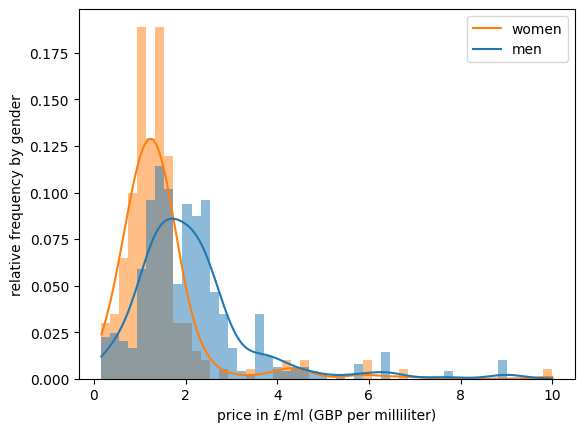

In [10]:
# visualisation
fig, ax = plt.subplots()
#
sns.histplot(
    ax = ax,
    data = df,
    x = "price_per_ml",
    hue = "gender", # show histplot by gender
    stat = "probability",
    common_norm = False, # to show the frequency FOR THAT GENDER only, not overall
    bins = 50,
    kde = True,
    edgecolor = "none",
)

ax.set_xlabel("price in £/ml (GBP per milliliter)")
ax.set_ylabel("relative frequency by gender")
ax.legend(["women", "men"])
#
plt.savefig("plots/EN/prices_pdf.png")
plt.show()

We observe that women's perfumes are higher on average, but not to a significant extent.
In addition, we can ignore outliers. However, since the focus of our analysis is on the text data (next), not the numerical data, we do not remove outlier products.

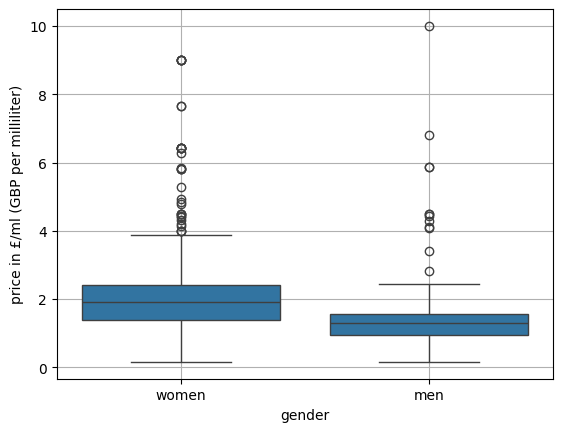

In [11]:
max_price = float('inf') # or 10 to ignore extreme outlier
sns.boxplot(data = df[(df.price_per_ml <= max_price)],
            y = "price_per_ml",
            x = "gender",
            );
plt.ylabel("price in £/ml (GBP per milliliter)")
plt.grid(True)
plt.savefig("plots/EN/prices_box.png")
plt.show()

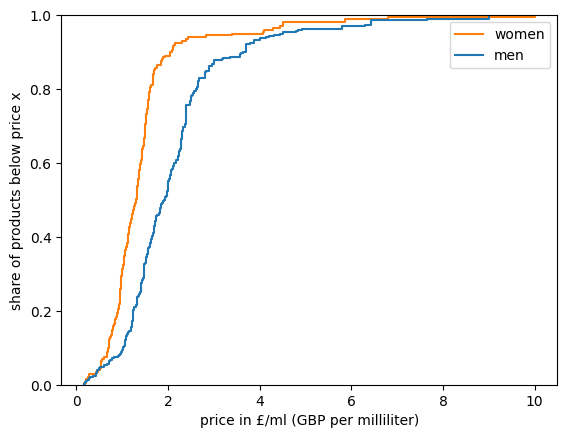

In [12]:
# compare the CDFs (cumulative density functions)
fig, ax = plt.subplots()
max_price = float('inf') # or 10 to ignore extreme outlier
#
sns.ecdfplot(ax = ax,
             data = df[df.price_per_ml <= max_price],
             x = "price_per_ml",
             hue = "gender"
)
#
ax.set_xlabel("price in £/ml (GBP per milliliter)")
ax.set_ylabel("share of products below price x")
ax.legend(["women", "men"])
#
plt.savefig("plots/EN/prices_cdf.png")
plt.show()

We have not observed statistically significant differences between men's and women's 	fragrances when looking at the numerical (price) data. Next, we turn to the text data: descriptions of the fragrances on their product details page.

## Textual data analysis / NLP

### data preparation

In [5]:
# load the data
df = pd.read_csv("data/webshop_data_scraped_EN.csv")

In [6]:
# explore the data
df.head()

,id,url,gender,description,price_per_ml
0,p10011349,https://www.sephora.co.uk/p/marc-jacobs-perfec...,women,"The playful and unexpected women's perfume, Pe...",2.20
1,p1000211524,https://www.sephora.co.uk/p/merit-beauty-retro...,women,Highlights. . . . . . ...,1.97
2,p1000210636,https://www.sephora.co.uk/p/fenty-hair-hair-bo...,women,Highlights. . . . . . ...,0.29
3,p1000210507,https://www.sephora.co.uk/p/charlotte-tilbury-...,women,\• FEEL LIKE A STAR!• SPRAY ME FOR… STAR CONFI...,1.60
4,p10023817,https://www.sephora.co.uk/p/mugler-alien-eau-d...,women,"Embodying a Solar Goddess, radiant and sensual...",2.60


We are interested in the "description" data - particularly how the wording varies between women's and men's fragrances. We first check for any repetitions in the data (multiple instances of a product) to avoid skewed results.

In [7]:
len(df) - df.description.nunique()

2

In [8]:
# for each gender, clean the data and gather the text descriptions
genders = ["women", "men"] # the website we look at works with a two-category gender dichotomy
# store them in a dictionary
dict_descriptions = {}
for gender in genders:
    descriptions = (df
                    [df.description.apply(lambda x: isinstance(x, str))] # keep only those with text description
                    .query("gender == @gender") # specify gender
                    .description # ignore all other columns
                    .drop_duplicates() # remove duplicate descriptions
                    .reset_index(drop=True)
    )
    dict_descriptions[gender] = descriptions

In [9]:
# explore the dictionary
dict_descriptions

{'women': 0      The playful and unexpected women's perfume, Pe...
 1      Highlights.                         . . . . . ...
 2      Highlights.                         . . . . . ...
 3      \• FEEL LIKE A STAR!• SPRAY ME FOR… STAR CONFI...
 4      Embodying a Solar Goddess, radiant and sensual...
                              ...                        
 494    A captivating attraction emanates from Givench...
 495    Highlights.                         . . . . . ...
 496    Roman at heart, Valentino Beauty is a color co...
 497    Highlights.                         . . . . . ...
 498    Ginza Eau de Parfum Murasaki, the new Shiseido...
 Name: description, Length: 499, dtype: str,
 'men': 0      Set includes . Halfeti Eau de Parfum, Quercus ...
 1      All in Adrenaline. With Azzaro Wanted Eau de P...
 2      Life is a game, are you ready to play and reac...
 3      The AZZARO WANTED saga continues, a new chapte...
 4      Be victorious with INVICTUS Victory Absolu Par...
           

### lemmatization

To identify word frequencies, we have to lemmatise, i.e. grouping together different inflections of a word. Furthermore, we will ignore stop words.

In [10]:
dict_lemmata = {}
for gender in genders:
    list_lemmata = []
    docs = nlp.pipe(dict_descriptions[gender]) # attention: this returns a generator, so we have to either store its output to a list or (as we will do) use it directly
    for doc in docs: # iterate over the descriptions per gender
        lemmata = [token.lemma_.lower() for token in doc if not (token.is_stop or token.is_punct)]
        # iterate over words/tokens per description. ignore stop words (and/or, the, ...) and punctuation (,/./-). make all lemmata lowercase since we otherwise get a lot of double counting from what Spacy sees as named entities such as "Jasmine" or "Rose" vs "jasmine" and "rose"
        list_lemmata.extend(lemmata)
    dict_lemmata[gender] = list_lemmata

In [11]:
# compare below the move from text description to lemmatization
print(dict_descriptions["women"][0])
print(dict_lemmata["women"][0:10])

The playful and unexpected women's perfume, Perfect Marc Jacobs Eau de Parfum for her, is a comforting floral scent that celebrates optimism, self-acceptance and originality.. . The perfume was inspired by Marc Jacobs’ mantra: “I am perfect as I am,” which is symbolised by a tattoo of the word “perfect” on his wrist. Like his tattoo, Perfect Marc Jacobs is about embracing and expressing one’s true self.. . Modern, bright, and feminine, Perfect is an unconventional yet harmonious clash of fresh floral and calming smooth notes. The fragrance opens with juicy notes of rhubarb and bright daffodil that reveal a comforting heart of almond milk. The fragrance finishes with a soft dry down of cedarwood and cashmeran.. . Perfect is nothing you would expect and everything it needs to be. #MJPerfect #PerfectAsIAm Perfect as a gift for a friend or daughter to show them how much you care for them or even as a treat to yourself.. . . . . . .     .             Ingredients. ALCOHOL DENAT., PARFUM/FRAG

In [12]:
# create dataframe with the lemmata (dfl) per gender
dfl_women = pd.DataFrame(dict_lemmata["women"])
dfl_women.columns = ["lemma"]
dfl_women.lemma.value_counts().head(15)

lemma
fragrance     1605
ingredient    1177
note          1077
alcohol       1019
parfum         975
benzyl         914
eau            786
               759
de             707
ci             645
scent          542
water          531
product        531
shop           509
packaging      502
Name: count, dtype: int64

In [13]:
# create dataframe with the lemmata (dfl) per gender
dfl_men = pd.DataFrame(dict_lemmata["men"])
dfl_men.columns = ["lemma"]
dfl_men.lemma.value_counts().head(15)

lemma
fragrance     676
ingredient    479
note          447
parfum        416
de            330
eau           328
alcohol       314
ci            269
              265
list          213
linalool      211
limonene      208
product       205
packaging     204
shop          202
Name: count, dtype: int64

### Document Term Matrix (DTM)

We are interested in the relative frequencies of word usage.

In [14]:
dtm_women = dfl_women.lemma.value_counts().reset_index(name="absolute")
dtm_women["relative"] = dtm_women["absolute"] / dtm_women.absolute.sum()
dtm_women

,lemma,absolute,relative
0,fragrance,1605,0.020815
1,ingredient,1177,0.015264
2,note,1077,0.013967
3,alcohol,1019,0.013215
4,parfum,975,0.012645
...,...,...,...
6441,uninhibited,1,0.000013
6442,asset,1,0.000013
6443,vaporize,1,0.000013
6444,intimacy,1,0.000013


In [15]:
dtm_men = dfl_men.lemma.value_counts().reset_index(name="absolute")
dtm_men["relative"] = dtm_men["absolute"] / dtm_men.absolute.sum()
dtm_men

,lemma,absolute,relative
0,fragrance,676,0.022985
1,ingredient,479,0.016287
2,note,447,0.015199
3,parfum,416,0.014145
4,de,330,0.011221
...,...,...,...
3608,noteslingering,1,0.000034
3609,cinnamonfragrance,1,0.000034
3610,notesanimal,1,0.000034
3611,hide,1,0.000034


We can now compare which words are more frequently occurring in women's vs. men's fragrances, see the `delta`.

In [16]:
dtm = pd.merge(dtm_women, dtm_men, on='lemma', how='outer', suffixes=('_women', '_men')).fillna(0)
dtm["delta"] = dtm.relative_women - dtm.relative_men
dtm.sort_values("delta")

,lemma,absolute_women,relative_women,absolute_men,relative_men,delta
4384,man,6.0,0.000078,190.0,0.006460,-0.006383
1239,boss,18.0,0.000233,107.0,0.003638,-0.003405
6898,toilette,82.0,0.001063,119.0,0.004046,-0.002983
1905,coumarin,277.0,0.003592,182.0,0.006188,-0.002596
1209,blue,75.0,0.000973,97.0,0.003298,-0.002326
...,...,...,...,...,...,...
2985,flower,280.0,0.003631,21.0,0.000714,0.002917
7437,woman,244.0,0.003164,5.0,0.000170,0.002994
5974,rose,353.0,0.004578,27.0,0.000918,0.003660
2965,floral,444.0,0.005758,37.0,0.001258,0.004500


### compare term frequencies

We narrow down on those words that have the highest `delta` in absolute terms, i.e. are overrepresented in the descriptions in one of the genders (and underrepresented in the other gender, respectively),

In [17]:
# create a new df from those words that are most over-/underrepresented in either text
words_genders = ["woman", "man", "homme", "feminine", "femininity", "masculine"] # excluded direct gender-references
words_terminology = ["perfume", "parfum", "toilette", "fragrance", "eau", "aftershave", "oil"] # account for different terminologies between female and male fragrances, as well as for chemical ingredients
words_compounds = ["benzyl", "butyl", "alcohol", "salicylate", "ethylhexyl", "methoxydibenzoylmethane", "hydroxycitronellal", "farnesol", "methoxycinnamate", "ionone"] # remove chemical compounds in the "ingredients" section at the bottom of each products page
words_brands = ["gucci", "dolce&gabbana"] # frequent words stemming for specific brand or product names
words_stop = ["de", "<", ">"] # additional irrelevant words, e.g. particles of brand names
more_exclusions = words_genders + words_terminology + words_compounds+ words_brands + words_stop
counter = 20 # how many words for each gender?
dtm_mask = dtm[["lemma", "delta"]].query("lemma not in @more_exclusions").sort_values("delta", ascending=False)
dtm_plot = pd.concat(
    [dtm_mask[:counter],
     dtm_mask[-counter:]],
     ignore_index=True
)
dtm_plot

,lemma,delta
0,floral,0.004500
1,rose,0.003660
2,flower,0.002917
3,jasmine,0.002572
4,white,0.001949
5,musk,0.001782
6,ylang,0.001284
7,pink,0.001202
8,collection,0.001174
9,bloom,0.001172


In [18]:
# store locally
dtm.to_csv("data/document_term_matrix_EN.csv", index=False)

### visualisation

We can now plot our key finding, visualising those words that are most over-represented in women's vs. men's fragrance descriptions.

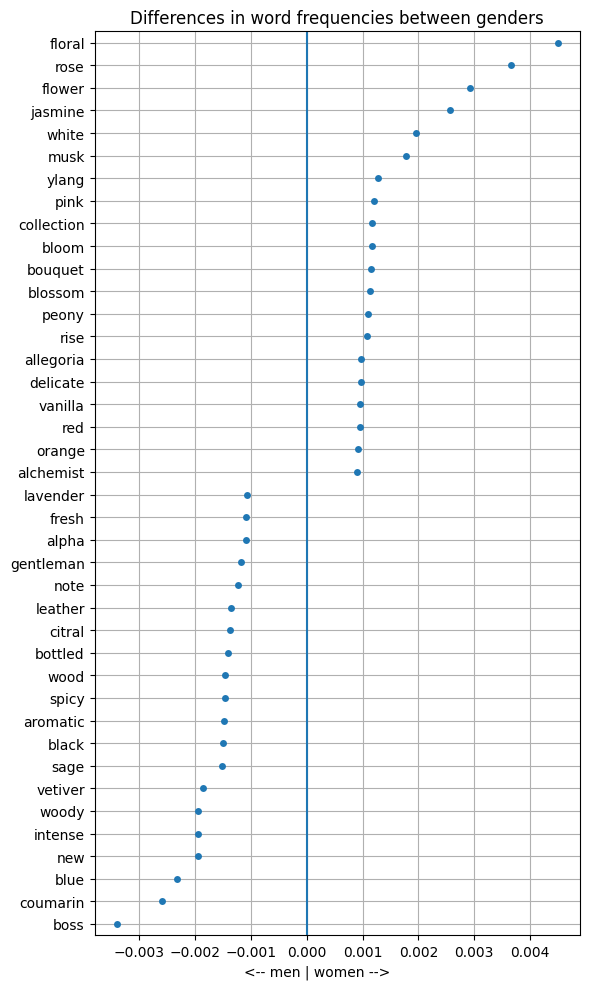

In [26]:
fig, ax = plt.subplots(figsize=(6, 10))
sns.swarmplot(data = dtm_plot, x = "delta", y = "lemma")
ax.axvline(0)
ax.set_ylabel("")
ax.set_xlabel("<-- men | women -->"
              + " "*9 # for horizontal shift of the label)
              )
ax.set_title("Differences in word frequencies between genders")
plt.grid()
fig.tight_layout()# to avoid clipping of the plot (particularly axes labels)

plt.savefig("plots/EN/word_frequencies.png")
plt.show()